In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from typing import Tuple, List
import os
import re

In [2]:
import pandas as pd
from typing import Tuple
import re

def parse_filenames(df: pd.DataFrame) -> pd.DataFrame:
    """Processes a DataFrame to extract sample, sampler, and method from filenames.
    
    It reads from a column 'Unnamed: 0', and creates 'sample',
    'sampler', and 'method' columns, then drops the original column.

    Args:
        df: The input pandas DataFrame.

    Returns:
        A new DataFrame with the processed columns.
    """
    
    # Work on a copy to avoid side effects and SettingWithCopyWarning
    df_copy = df.copy()
    
    # The name of the column containing the filenames
    filename_col = 'Unnamed: 0'

    def parse_filename(filename: str) -> Tuple[str, str, str]:
        """Parses a filename to extract sample, sampler, and method.

        Handles formats like:
        - `doublet_1_NR_groupwise` -> sample: 1, sampler: NR, method: groupwise
        - `doublets_1_null_singlets_groupwise` -> sample: 1, sampler: RJ, method: groupwise
        - `flowmop_doublets_1` -> sample: 1, sampler: FlowMOP, method: groupwise

        Args:
            filename: The filename string to parse.

        Returns:
            A tuple containing the sample, sampler, and method.
        """
        
        # Clean the filename by removing the extension and any whitespace
        clean_name = filename.replace('.fcs', '').strip()
        parts = clean_name.split('_')
        
        sample, sampler, method = '', '', ''

        # Handle flowmop format: e.g., flowmop_doublets_1 or flowmop_doublet_4
        if parts[0] == 'flowmop' and parts[1].startswith('doublet'):
            sample = parts[2]
            sampler = 'FlowMOP'
            method = 'groupwise'
        # Handle other doublet formats
        elif parts[0].startswith('doublet'):
            sample = parts[1]
            method = parts[-1]
            
            if 'null' in parts:
                sampler = 'RJ'
            else:
                sampler = parts[2]
            
        return sample, sampler, method

    # Apply the parsing function to the column to create new columns
    df_copy[['sample', 'sampler', 'method']] = df_copy[filename_col].apply(
        lambda name: pd.Series(parse_filename(name))
    )
    
    # Drop the original 'Unnamed: 0' column
    df_processed = df_copy.drop(columns=[filename_col])
    
    return df_processed

In [3]:
synth_dir = r"C:\Users\Tony\Documents\github_remotes\FlowMOP\figs\fig_2_data\fig_2_analysis"
csvs = [f for f in os.listdir(synth_dir) if f.endswith('.csv')]
doublet_data = [pd.read_csv(synth_dir + "\\" + csv).iloc[:22] for csv in csvs if 'doublet' in csv]
for i, doublet in enumerate(doublet_data): 
    doublet_data[i] = doublet_data[i][~doublet_data[i]['Unnamed: 0'].str.contains('Mean', na=False)]
    doublet_data[i] = doublet_data[i][~doublet_data[i]['Unnamed: 0'].str.contains('SD', na=False)]
    

for i, time in enumerate(doublet_data): 
    doublet_data[i] = parse_filenames(time).sort_values(by="sample").reset_index(drop=True)
original_count = doublet_data[0]["Count"]
original_doublets = doublet_data[0]["Q2: CTV+ , CFSE+ | Freq. of Parent (%)"]
doublet_data[0]["Count"] = doublet_data[0]["Count"] * doublet_data[0]["passeddoublet subset | Freq. of Parent (%)"]/100

In [4]:
doublet_data[0].rename(columns={
    "passeddoublet subset/Q2: CTV+ , CFSE+ | Freq. of Parent (%)":"doublets",
    }, inplace=True)
# Drop all columns containing '|' in their names
columns_to_drop = [col for col in doublet_data[0].columns if '|' in col]
doublet_data[0].drop(columns=columns_to_drop, inplace=True)
doublet_data[0].drop(columns=["Unnamed: 11"], inplace=True)

doublet_data[1].drop("Unnamed: 6", axis=1, inplace=True)
doublet_data[1].rename(columns={
    "Q2: CTV+ , CFSE+ | Freq. of Parent (%)": "doublets",
    }, inplace=True)
# Drop all columns containing '|' in their names
columns_to_drop = [col for col in doublet_data[1].columns if '|' in col]
doublet_data[1].drop(columns=columns_to_drop, inplace=True)
doublet_data[1].drop([6], inplace=True)

In [5]:
all_doublets = pd.concat([doublet_data[0], doublet_data[1]])

In [6]:
flowmop_data = all_doublets[all_doublets['sampler'] == 'FlowMOP']
from scipy import stats

# Perform paired t-test between initial_sample and flowmop_data doublets
t_stat, p_value = stats.ttest_rel(original_doublets, flowmop_data['doublets'])

print(f"Paired t-test results:")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

# Print summary statistics for context
print(f"\nSummary statistics:")
print(f"Initial sample mean: {original_doublets.mean():.2f}")
print(f"FlowMOP doublets mean: {flowmop_data['doublets'].mean():.2f}")
print(f"Initial sample std: {original_doublets.std():.2f}")
print(f"FlowMOP doublets std: {flowmop_data['doublets'].std():.2f}")



Paired t-test results:
t-statistic: 12.2388
p-value: 0.0012

Summary statistics:
Initial sample mean: 7.84
FlowMOP doublets mean: 0.27
Initial sample std: 1.21
FlowMOP doublets std: 0.11


In [10]:
# Create a mapping from sample ID to the original doublet percentage.
# We know 'original_doublets' corresponds to samples '1', '2', '3', '4' in order,
# because the DataFrame was sorted by sample before 'original_doublets' was extracted.
sample_ids = sorted(all_doublets['sample'].unique())
original_doublets_map = pd.Series(original_doublets.values, index=sample_ids)

# Create a copy to avoid SettingWithCopyWarning
all_doublets_copy = all_doublets.copy()

# Map the original doublet values to the all_doublets DataFrame based on the 'sample' column
all_doublets_copy['original_doublet'] = all_doublets_copy['sample'].map(original_doublets_map)

# Calculate the difference
all_doublets_copy['doublet_difference'] = 100 - (all_doublets_copy['original_doublet'] - all_doublets_copy['doublets'])

C:\Users\Tony\AppData\Local\Temp\ipykernel_34788\778338091.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Tony\AppData\Local\Temp\ipykernel_34788\778338091.py:74: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


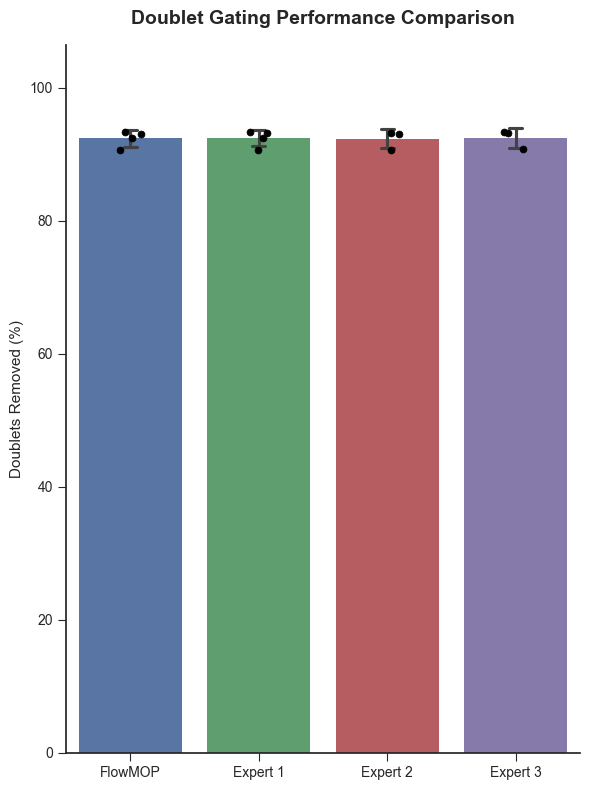

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# --- 1. Data Preparation ---

# Create a DataFrame for plotting.
# We will use the 'samplewise' method for experts and the only available method for FlowMOP.
plot_df = all_doublets_copy[
    (all_doublets_copy['method'] == 'samplewise') | 
    (all_doublets_copy['sampler'] == 'FlowMOP')
].copy()

# Anonymize sampler names for a clean plot legend.
anonymize_map = {
    'FlowMOP': 'FlowMOP',
    'FMW': 'Expert 1',
    'NR': 'Expert 2',
    'RJ': 'Expert 3'
}
plot_df['sampler_anonymized'] = plot_df['sampler'].map(anonymize_map)

# --- 2. Statistical Analysis (Paired t-test) ---

# Get the scores for FlowMOP, indexed by sample.
flowmop_scores = plot_df[plot_df['sampler_anonymized'] == 'FlowMOP'].set_index('sample')['doublet_difference']

p_values = {}
experts = ['Expert 1', 'Expert 2', 'Expert 3']
for expert in experts:
    # Get scores for the current expert, indexed by sample.
    expert_scores = plot_df[plot_df['sampler_anonymized'] == expert].set_index('sample')['doublet_difference']
    
    # Align scores by sample index to ensure proper pairing for the t-test.
    # This handles cases where an expert might be missing a sample.
    merged_scores = pd.merge(
        flowmop_scores.rename('flowmop'),
        expert_scores.rename('expert'),
        left_index=True,
        right_index=True
    )
    
    # Perform the paired t-test.
    t_stat, p_val = stats.ttest_rel(merged_scores['flowmop'], merged_scores['expert'])
    p_values[expert] = p_val

# Apply Bonferroni correction for multiple comparisons.
n_tests = len(p_values)

# --- 3. Publication-Style Plotting with Significance Connectors ---

# Use a clean, professional style for the plot.
plt.style.use('seaborn-v0_8-ticks')
fig, ax = plt.subplots(figsize=(6, 8))

# Define the order and color palette for the samplers.
order = ['FlowMOP', 'Expert 1', 'Expert 2', 'Expert 3']
palette = ['#4c72b0', '#55a868', '#c44e52', '#8172b2']

# Create the bar plot showing mean and standard deviation.
sns.barplot(
    x='sampler_anonymized',
    y='doublet_difference',
    data=plot_df,
    order=order,
    palette=palette,
    errorbar='sd',
    capsize=0.1,
    ax=ax
)

# Overlay individual data points.
sns.stripplot(
    x='sampler_anonymized',
    y='doublet_difference',
    data=plot_df,
    order=order,
    color='black',
    size=5,
    jitter=0.1,
    ax=ax,
    edgecolor='gray',
    linewidth=0.5
)

# Refine plot titles and labels.
ax.set_title('Doublet Gating Performance Comparison', fontsize=14, weight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Doublets Removed (%)', fontsize=11)
ax.tick_params(axis='both', which='major', labelsize=10)
sns.despine()

# Helper function to draw significance bars.
def add_significance_bar(x1, x2, p_corrected, y_pos, ax):
    """Draws a significance bar between two x-levels."""
    if p_corrected >= 0.05:
        return

    # Determine significance symbol based on p-value.
    if p_corrected < 0.001: s_text = '***'
    elif p_corrected < 0.01: s_text = '**'
    else: s_text = '*'
    
    tick_len = 0.5
    
    # Draw the connecting line and ticks.
    ax.plot([x1, x2], [y_pos, y_pos], c='k', lw=1.2)
    ax.plot([x1, x1], [y_pos - tick_len, y_pos], c='k', lw=1.2)
    ax.plot([x2, x2], [y_pos - tick_len, y_pos], c='k', lw=1.2)
    
    # Add the significance text above the bar.
    ax.text((x1 + x2) / 2, y_pos, s_text,
            va='bottom', ha='center', fontsize=12, weight='bold')

# Calculate the vertical positions for the significance bars.
max_y = plot_df.groupby('sampler_anonymized')['doublet_difference'].apply(lambda x: x.mean() + x.std()).max()
bar_y_pos = max_y * 1.08
y_increment = max_y * 0.1

# Add a significance bar for each comparison.
x_flowmop = order.index('FlowMOP')
for expert in order[1:]:
    p_corrected = min(p_values[expert] * n_tests, 1.0)
    if p_corrected < 0.05:
        x_expert = order.index(expert)
        add_significance_bar(x_flowmop, x_expert, p_corrected, bar_y_pos, ax)
        bar_y_pos += y_increment

# Final adjustments to the plot layout.
ax.set_ylim(top=bar_y_pos * 1.05)
plt.tight_layout()
plt.show()


Could not perform t-test for Expert 2: unequal number of samples or no samples.


C:\Users\Tony\AppData\Local\Temp\ipykernel_34788\3982794661.py:61: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
C:\Users\Tony\AppData\Local\Temp\ipykernel_34788\3982794661.py:61: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


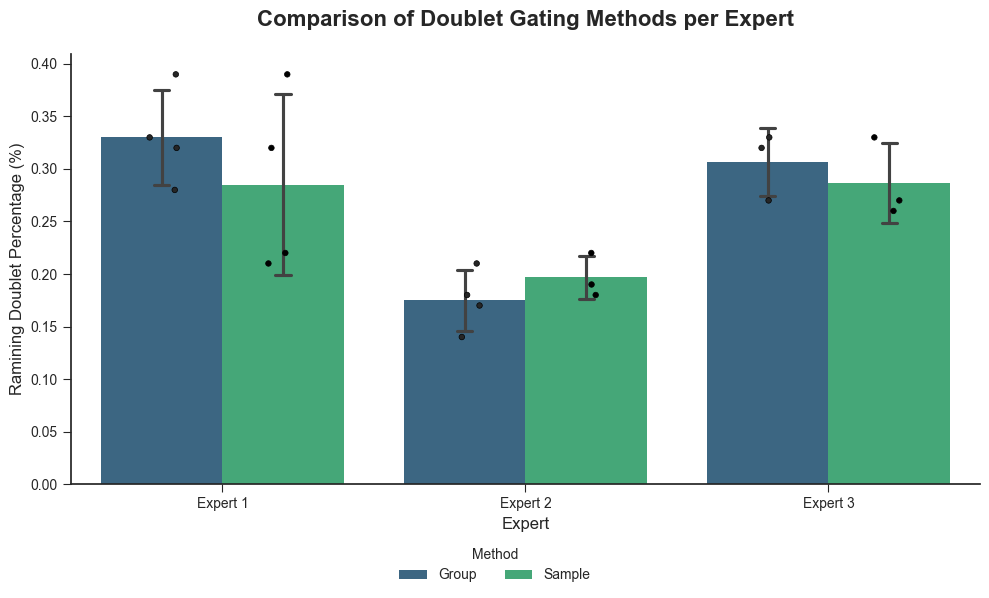

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import pandas as pd

# 1. Data Preparation
# Filter for human experts and create a copy to avoid SettingWithCopyWarning
experts_df = all_doublets[all_doublets['sampler'] != 'FlowMOP'].copy()

# Anonymize sampler names
anonymize_map = {
    'FMW': 'Expert 1',
    'NR': 'Expert 2',
    'RJ': 'Expert 3'
}
experts_df['sampler_anonymized'] = experts_df['sampler'].map(anonymize_map)

# Capitalize method names for a cleaner legend in the plot
experts_df['method'] = experts_df['method'].str.replace('wise', '').str.capitalize()

# 2. Paired T-tests
# Compare 'groupwise' vs 'samplewise' for each expert
p_values_method_comparison = {}
experts = ['Expert 1', 'Expert 2', 'Expert 3']

for expert in experts:
    expert_df = experts_df[experts_df['sampler_anonymized'] == expert]
    
    # Ensure the data is sorted by sample to correctly pair the measurements
    groupwise_scores = expert_df[expert_df['method'] == 'Group'].sort_values('sample')['doublets']
    samplewise_scores = expert_df[expert_df['method'] == 'Sample'].sort_values('sample')['doublets']
    
    # The lengths of the series must be equal for a paired t-test
    if len(groupwise_scores) == len(samplewise_scores) and len(groupwise_scores) > 0:
        t_stat, p_val = stats.ttest_rel(groupwise_scores, samplewise_scores)
        p_values_method_comparison[expert] = p_val
    else:
        print(f"Could not perform t-test for {expert}: unequal number of samples or no samples.")
        p_values_method_comparison[expert] = 1.0 # Assign a non-significant p-value

# 3. Create the Plot
plt.style.use('seaborn-v0_8-ticks')
fig, ax = plt.subplots(figsize=(10, 6))

order = ['Expert 1', 'Expert 2', 'Expert 3']
# Create the grouped bar plot
sns.barplot(
    x='sampler_anonymized', 
    y='doublets', 
    hue='method', 
    data=experts_df, 
    order=order,
    palette='viridis',
    errorbar='sd',
    capsize=0.1,
    ax=ax
)

# Overlay individual data points
sns.stripplot(
    x='sampler_anonymized',
    y='doublets',
    hue='method',
    data=experts_df,
    order=order,
    dodge=True,
    color='black',
    size=4,
    jitter=0.1,
    ax=ax,
    edgecolor='gray',
    linewidth=0.5
)

# 4. Add Significance Annotations
def add_significance_bracket(x_center, p_val, ax, experts_df, order):
    """Draws a significance bracket over a group of bars."""
    if p_val >= 0.05:
        return

    if p_val < 0.001:
        s_text = '***'
    elif p_val < 0.01:
        s_text = '**'
    else:
        s_text = '*'
    
    # Determine the top of the bars for the current group to place the bracket
    expert_name = order[int(round(x_center))]
    group_data = experts_df[experts_df['sampler_anonymized'] == expert_name]
    
    # Calculate the mean + std dev for both methods to find the highest point
    max_y = 0
    for method in ['Group', 'Sample']:
        method_data = group_data[group_data['method'] == method]['doublets']
        if not method_data.empty:
            mean_val = method_data.mean()
            std_val = method_data.std()
            max_y = max(max_y, mean_val + std_val)

    bar_width = 0.4
    x1 = x_center - bar_width / 2
    x2 = x_center + bar_width / 2
    
    # Position the bracket slightly above the highest bar/error bar
    y_bracket = max_y + 0.05 * ax.get_ylim()[1]
    bracket_height = 0.02 * ax.get_ylim()[1]
    
    ax.plot([x1, x1, x2, x2], [y_bracket, y_bracket + bracket_height, y_bracket + bracket_height, y_bracket], c='k', lw=1.2)
    ax.text((x1 + x2) / 2, y_bracket + bracket_height, s_text,
            ha='center', va='bottom', fontsize=12, weight='bold')

# Add annotations for each expert
for i, expert in enumerate(order):
    if expert in p_values_method_comparison:
        p_val = p_values_method_comparison[expert]
        add_significance_bracket(i, p_val, ax, experts_df, order)

# 5. Final Touches
ax.set_title('Comparison of Doublet Gating Methods per Expert', fontsize=16, weight='bold', pad=20)
ax.set_xlabel('Expert', fontsize=12)
ax.set_ylabel('Ramining Doublet Percentage (%)', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=10)

# Get handles and labels, then remove the default legend
handles, labels = ax.get_legend_handles_labels()
if ax.get_legend() is not None:
    ax.get_legend().remove()

# Add a new legend at the bottom of the figure
fig.legend(
    handles[:2], 
    labels[:2], 
    title='Method', 
    bbox_to_anchor=(0.5, 0), 
    loc='lower center', 
    ncol=2, 
    frameon=False
)

sns.despine()

# Adjust layout to make space for the legend
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()